In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


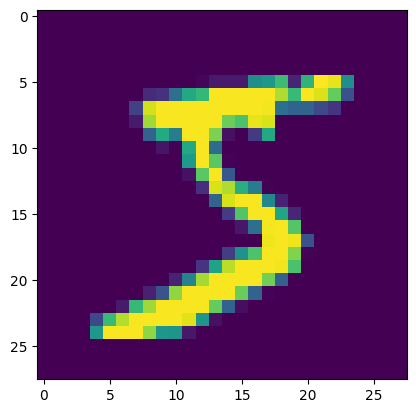

In [ ]:
x_train[0]
plt.imshow(x_train[0])

In [ ]:
x_train = x_train/255
x_test = x_test/255

In [ ]:
model = Sequential()
model.add(Flatten(input_shape=(28,28)))  #flatten=extracts features
model.add(Dense(128, activation='relu'))  #neurons = 128 (default)
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary ()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile (loss = 'sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
#model fit
model.fit (x_train, y_train, epochs=10, validation_split = 0.2) # (batch_size = 32)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9980 - loss: 0.0063 - val_accuracy: 0.9779 - val_loss: 0.1117
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9989 - loss: 0.0039 - val_accuracy: 0.9801 - val_loss: 0.1044
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9797 - val_loss: 0.1133
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9981 - loss: 0.0057 - val_accuracy: 0.9778 - val_loss: 0.1192
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9991 - loss: 0.0032 - val_accuracy: 0.9785 - val_loss: 0.1206
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9988 - loss: 0.0040 - val_accuracy: 0.9763 - val_loss: 0.1277
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9988 - loss: 0.0041 - val_accuracy: 0.9769 - val_loss: 0.1244
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9994 - loss: 0.0028 -

In [ ]:
#testing model
model.predict (x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[6.9953832e-10, 1.2453534e-12, 2.3876515e-07, ..., 9.9987435e-01,
        1.6279202e-07, 6.5098839e-06],
       [1.4740929e-11, 1.5199355e-06, 9.9999839e-01, ..., 2.3675220e-18,
        4.9065097e-08, 6.4701551e-17],
       [6.7881158e-09, 9.9981856e-01, 8.8890629e-06, ..., 1.0117492e-05,
        1.5611650e-04, 7.0917253e-08],
       ...,
       [2.6375264e-19, 2.0702246e-13, 2.7532045e-17, ..., 3.4552517e-08,
        1.3222475e-09, 1.1704477e-06],
       [3.9654851e-15, 4.6725832e-18, 4.0525088e-18, ..., 6.3616045e-15,
        4.9508388e-09, 1.9035654e-14],
       [9.3977071e-10, 2.6932544e-13, 1.6108030e-10, ..., 1.4139805e-15,
        2.0669818e-11, 1.6637263e-11]], dtype=float32)

In [ ]:
y_prob = model.predict(x_test)
print (y_prob)
y_pred = y_prob.argmax (axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[6.9953832e-10 1.2453534e-12 2.3876515e-07 ... 9.9987435e-01
  1.6279202e-07 6.5098839e-06]
 [1.4740929e-11 1.5199355e-06 9.9999839e-01 ... 2.3675220e-18
  4.9065097e-08 6.4701551e-17]
 [6.7881158e-09 9.9981856e-01 8.8890629e-06 ... 1.0117492e-05
  1.5611650e-04 7.0917253e-08]
 ...
 [2.6375264e-19 2.0702246e-13 2.7532045e-17 ... 3.4552517e-08
  1.3222475e-09 1.1704477e-06]
 [3.9654851e-15 4.6725832e-18 4.0525088e-18 ... 6.3616045e-15
  4.9508388e-09 1.9035654e-14]
 [9.3977071e-10 2.6932544e-13 1.6108030e-10 ... 1.4139805e-15
  2.0669818e-11 1.6637263e-11]]


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy_score (y_test, y_pred)


0.9764

In [ ]:
history=model.fit (x_train, y_train, epochs = 10, validation_split=0.2, )


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9990 - loss: 0.0038 - val_accuracy: 0.9781 - val_loss: 0.1341
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9992 - loss: 0.0027 - val_accuracy: 0.9753 - val_loss: 0.1535
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9988 - loss: 0.0042 - val_accuracy: 0.9777 - val_loss: 0.1342
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9998 - loss: 0.0012 - val_accuracy: 0.9796 - val_loss: 0.1294
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9980 - loss: 0.0055 - val_accuracy: 0.9768 - val_loss: 0.1425
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9998 - loss: 9.3650e-04 - val_accuracy: 0.9777 - val_loss: 0.1449
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9990 - loss: 0.0039 - val_accuracy: 0.9794 - val_loss: 0.1492
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9989 - loss: 0.00

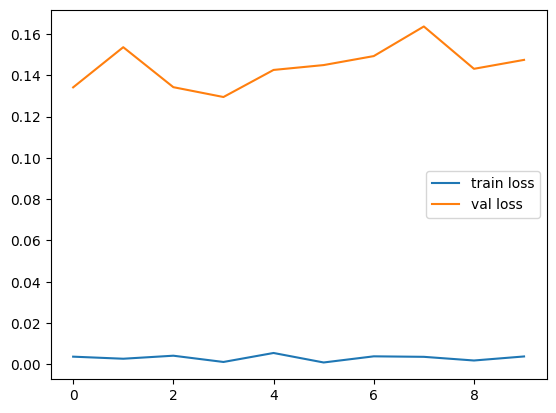

In [ ]:
plt.plot (history.history['loss'], label='train loss')
plt.plot (history.history['val_loss'], label='val loss')
plt.legend ()
plt.show ()

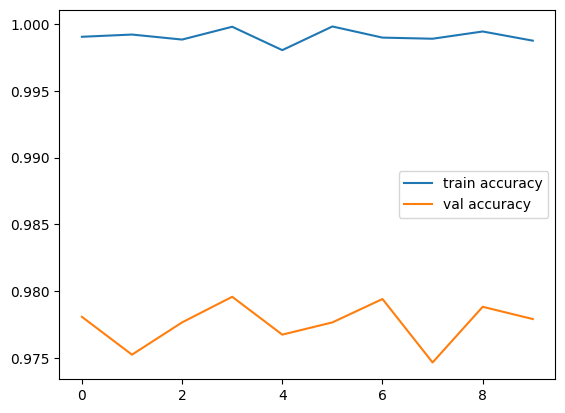

In [ ]:
#PLOT FOR ACCURACY
plt.plot (history.history['accuracy'], label='train accuracy')
plt.plot (history.history['val_accuracy'], label='val accuracy')
plt.legend ()
plt.show ()